# Sistemas Inteligentes I
## Búsqueda informada: Costo Uniforme, A* y Beam Search

**Autor:** Jairo I. Vélez B.

### Propósito
Estudiar tres estrategias para decidir qué nodo expandir primero usando el costo acumulado y, cuando corresponde, una heurística.

Al finalizar, el estudiante podrá:
- diferenciar búsqueda no informada e informada;
- interpretar $g(n)$, $h(n)$ y $f(n)$;
- implementar Costo Uniforme, A* y Beam Search;
- comparar costo, estados expandidos y calidad de solución;
- analizar el efecto de una heurística.

# 1. Idea central

En BFS y DFS la frontera se organiza sin estimar qué nodo está más cerca del objetivo. En búsqueda informada podemos incorporar información adicional.

- $g(n)$: costo acumulado desde el inicio hasta $n$.
- $h(n)$: estimación del costo desde $n$ hasta el objetivo.
- En A*: $f(n)=g(n)+h(n)$.

**Costo Uniforme:** prioriza menor $g(n)$.  
**A\*:** prioriza menor $g(n)+h(n)$.  
**Beam Search:** conserva solo los mejores $k$ candidatos de cada nivel.

In [1]:
from heapq import heappush, heappop
from itertools import count
import math
import matplotlib.pyplot as plt

print("Entorno listo")

Entorno listo


# 2. Problema base: grafo ponderado

- Estado inicial: `A`
- Objetivo: `G`
- Cada arista tiene un costo.

In [2]:
grafo = {
    "A": {"B": 2, "C": 4},
    "B": {"D": 5, "E": 10},
    "C": {"E": 3, "F": 6},
    "D": {"G": 4},
    "E": {"G": 2},
    "F": {"G": 3},
    "G": {}
}
grafo

{'A': {'B': 2, 'C': 4},
 'B': {'D': 5, 'E': 10},
 'C': {'E': 3, 'F': 6},
 'D': {'G': 4},
 'E': {'G': 2},
 'F': {'G': 3},
 'G': {}}

# 3. Búsqueda de Costo Uniforme (UCS)

Expande el nodo con menor costo acumulado:

$$f(n)=g(n)$$

No usa heurística. La frontera se implementa con una cola de prioridad.

In [3]:
def costo_uniforme(grafo, inicio, objetivo):
    orden = count()
    frontera = []
    heappush(frontera, (0, next(orden), inicio, [inicio]))
    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}

        for vecino, costo in grafo[nodo].items():
            nuevo_g = g + costo
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                heappush(frontera, (nuevo_g, next(orden), vecino, camino + [vecino]))
    return None

resultado_ucs = costo_uniforme(grafo, "A", "G")
resultado_ucs

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

## 3.1 UCS paso a paso

In [4]:
def ucs_debug(grafo, inicio, objetivo):
    orden = count(); frontera=[]
    heappush(frontera,(0,next(orden),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(g,n) for g,_,n,_ in frontera])
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        print(f"Expandimos {nodo}: g={g}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(orden),vecino,camino+[vecino]))
        paso += 1

ucs_debug(grafo,"A","G")


Paso 1
Frontera: [(0, 'A')]
Expandimos A: g=0

Paso 2
Frontera: [(2, 'B'), (4, 'C')]
Expandimos B: g=2

Paso 3
Frontera: [(4, 'C'), (7, 'D'), (12, 'E')]
Expandimos C: g=4

Paso 4
Frontera: [(7, 'D'), (10, 'F'), (7, 'E'), (12, 'E')]
Expandimos D: g=7

Paso 5
Frontera: [(7, 'E'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos E: g=7

Paso 6
Frontera: [(9, 'G'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos G: g=9


(['A', 'C', 'E', 'G'], 9)

# 4. Heurística

Hasta ahora, **Costo Uniforme** solo utiliza información sobre el costo ya recorrido:

\[
g(n)
\]

Para orientar la búsqueda hacia el objetivo podemos incorporar una estimación:

\[
h(n)
\]

donde \(h(n)\) representa una **estimación del costo mínimo restante** desde el nodo \(n\) hasta el objetivo.

## ¿De dónde salen estos valores?

En un problema real, una heurística debe derivarse de alguna propiedad del dominio: distancia geométrica, cantidad de elementos fuera de lugar, una relajación del problema, conocimiento experto, etc.

En este grafo pequeño conocemos toda la estructura, por lo que podemos calcular el costo real mínimo desde cada nodo hasta `G`. Lo usaremos únicamente con fines didácticos para evaluar la calidad de una heurística.

In [5]:
# Costo real mínimo desde cada nodo hasta G.
# En un problema real normalmente NO conoceríamos estos valores de antemano.

costo_real_hasta_G = {
    "A": 9,
    "B": 9,
    "C": 5,
    "D": 4,
    "E": 2,
    "F": 3,
    "G": 0,
}

costo_real_hasta_G

{'A': 9, 'B': 9, 'C': 5, 'D': 4, 'E': 2, 'F': 3, 'G': 0}

## 4.1 Costo real vs. estimación heurística

Denotaremos el costo real mínimo restante como:

$$
h^*(n)
$$

La heurística $$h(n)$$ intenta aproximarlo:

$$
h(n)\approx h^*(n)
$$

Una heurística es **admisible** cuando nunca sobreestima el costo real:

$$
\boxed{h(n)\leq h^*(n)}
$$

Para este ejemplo utilizaremos una heurística **admisible pero imperfecta**:

| Nodo | $$h(n)$$ | $$h^*(n)$$ |
|---|---:|---:|
| A | 7 | 9 |
| B | 6 | 9 |
| C | 4 | 5 |
| D | 3 | 4 |
| E | 2 | 2 |
| F | 2 | 3 |
| G | 0 | 0 |

La heurística no conoce exactamente la solución: solo proporciona una estimación razonable.

In [6]:
heuristica = {
    "A": 7,
    "B": 6,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 2,
    "G": 0,
}

heuristica

{'A': 7, 'B': 6, 'C': 4, 'D': 3, 'E': 2, 'F': 2, 'G': 0}

In [7]:
# Verificación de admisibilidad
comparacion_heuristica = {
    nodo: {
        "h(n)": heuristica[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "admisible": heuristica[nodo] <= costo_real_hasta_G[nodo],
    }
    for nodo in heuristica
}

comparacion_heuristica

{'A': {'h(n)': 7, 'h*(n)': 9, 'admisible': True},
 'B': {'h(n)': 6, 'h*(n)': 9, 'admisible': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'admisible': True},
 'D': {'h(n)': 3, 'h*(n)': 4, 'admisible': True},
 'E': {'h(n)': 2, 'h*(n)': 2, 'admisible': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'admisible': True},
 'G': {'h(n)': 0, 'h*(n)': 0, 'admisible': True}}

### Idea clave

> **La heurística no tiene que acertar exactamente. Tiene que estimar.**

Una heurística demasiado débil puede aportar poca información.  
Una heurística que sobreestima puede orientar de manera agresiva la búsqueda, pero puede perder garantías de optimalidad.

# 5. A*

A* combina costo acumulado y estimación:

$$\boxed{f(n)=g(n)+h(n)}$$

Se expande primero el nodo con menor $f(n)$.

In [8]:
def a_estrella(grafo, heuristica, inicio, objetivo):
    tie = count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; expandidos=0

    while frontera:
        f,g,_,nodo,camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}

        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar = a_estrella(grafo,heuristica,"A","G")
resultado_astar

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

## 5.1 A* paso a paso

In [9]:
def astar_debug(grafo, heuristica, inicio, objetivo):
    tie=count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(n,g,f) for f,g,_,n,_ in frontera])
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        print(f"Expandimos {nodo}: g={g}, h={heuristica[nodo]}, f={f}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
        paso += 1

astar_debug(grafo,heuristica,"A","G")


Paso 1
Frontera: [('A', 0, 7)]
Expandimos A: g=0, h=7, f=7

Paso 2
Frontera: [('B', 2, 8), ('C', 4, 8)]
Expandimos B: g=2, h=6, f=8

Paso 3
Frontera: [('C', 4, 8), ('D', 7, 10), ('E', 12, 14)]
Expandimos C: g=4, h=4, f=8

Paso 4
Frontera: [('E', 7, 9), ('F', 10, 12), ('D', 7, 10), ('E', 12, 14)]
Expandimos E: g=7, h=2, f=9

Paso 5
Frontera: [('G', 9, 9), ('D', 7, 10), ('E', 12, 14), ('F', 10, 12)]
Expandimos G: g=9, h=0, f=9


(['A', 'C', 'E', 'G'], 9)

## 5.2 Tres casos para entender el papel de la heurística

Antes de comparar los algoritmos, observemos qué ocurre con A* bajo tres configuraciones distintas de \(h(n)\).

### Caso 1 — Sin heurística

Si:

$$
h(n)=0 \quad \forall n
$$

entonces:

$$
f(n)=g(n)
$$

y A* se comporta como **Costo Uniforme**.

In [10]:
heuristica_cero = {nodo: 0 for nodo in grafo}

resultado_astar_h0 = a_estrella(
    grafo,
    heuristica_cero,
    "A",
    "G"
)

resultado_astar_h0

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

### Caso 2 — Heurística admisible

Usamos la heurística definida anteriormente:

$$
h(n)\leq h^*(n)
$$

La búsqueda dispone de información para orientar la expansión sin sobreestimar el costo real restante.

In [11]:
resultado_astar_admisible = a_estrella(
    grafo,
    heuristica,
    "A",
    "G"
)

resultado_astar_admisible

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

### Caso 3 — Heurística que sobreestima

Ahora construiremos deliberadamente una heurística **no admisible**.

Algunos valores cumplen:

$$
h(n)>h^*(n)
$$

Esto no significa que A* necesariamente encuentre una mala solución, pero ya no podemos asumir las mismas garantías de optimalidad.

In [12]:
heuristica_sobreestima = {
    "A": 12,  # costo real = 9
    "B": 10,  # costo real = 9
    "C": 4,
    "D": 3,
    "E": 7,   # costo real = 2
    "F": 2,
    "G": 0,
}

comparacion_sobreestimacion = {
    nodo: {
        "h(n)": heuristica_sobreestima[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "sobreestima": heuristica_sobreestima[nodo] > costo_real_hasta_G[nodo],
    }
    for nodo in heuristica_sobreestima
}

comparacion_sobreestimacion

{'A': {'h(n)': 12, 'h*(n)': 9, 'sobreestima': True},
 'B': {'h(n)': 10, 'h*(n)': 9, 'sobreestima': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'sobreestima': False},
 'D': {'h(n)': 3, 'h*(n)': 4, 'sobreestima': False},
 'E': {'h(n)': 7, 'h*(n)': 2, 'sobreestima': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'sobreestima': False},
 'G': {'h(n)': 0, 'h*(n)': 0, 'sobreestima': False}}

In [13]:
resultado_astar_sobreestima = a_estrella(
    grafo,
    heuristica_sobreestima,
    "A",
    "G"
)

resultado_astar_sobreestima

{'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}

### Comparación de los tres casos

Compare:

- camino encontrado,
- costo total,
- nodos expandidos.

La idea importante es que una heurística no admisible **no necesariamente falla siempre**; simplemente deja de cumplir las condiciones que permiten garantizar la optimalidad de A*.

In [14]:
comparacion_tres_heuristicas = {
    "h(n)=0": resultado_astar_h0,
    "Admisible": resultado_astar_admisible,
    "Sobreestima": resultado_astar_sobreestima,
}

comparacion_tres_heuristicas

{'h(n)=0': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6},
 'Admisible': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5},
 'Sobreestima': {'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}}

# 6. Comparación inicial

**Pregunta clave:** ¿qué ocurre si $h(n)=0$ para todos los nodos?  
A* se comporta como Costo Uniforme.

In [15]:
{
    "Costo Uniforme": resultado_ucs,
    "A*": resultado_astar
}

{'Costo Uniforme': {'camino': ['A', 'C', 'E', 'G'],
  'costo': 9,
  'expandidos': 6},
 'A*': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}}

# 7. Caso aplicado: cuadrícula

Ahora trabajaremos con un mapa:

- `0`: celda libre
- `1`: obstáculo
- acciones: arriba, abajo, izquierda y derecha
- costo de cada movimiento: 1

Para A* usaremos distancia Manhattan:

$$h(n)=|x_n-x_g|+|y_n-y_g|$$

In [16]:
mapa = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,1,0,1,0,0,0],
    [0,0,0,0,1,1,0],
    [0,1,1,0,0,0,0],
    [0,0,0,0,1,0,0],
]
INICIO=(0,0); OBJETIVO=(6,6)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

## 7.1 Costo Uniforme en la cuadrícula

In [17]:
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 35}

## 7.2 A* en la cuadrícula

In [18]:
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 29}

## 7.3 Visualización

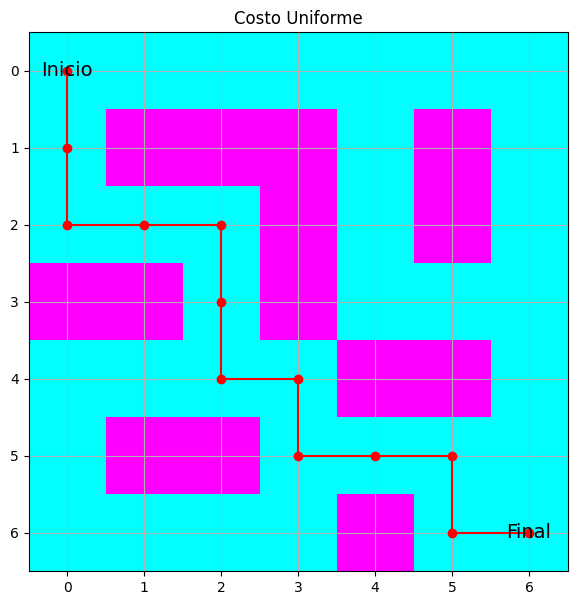

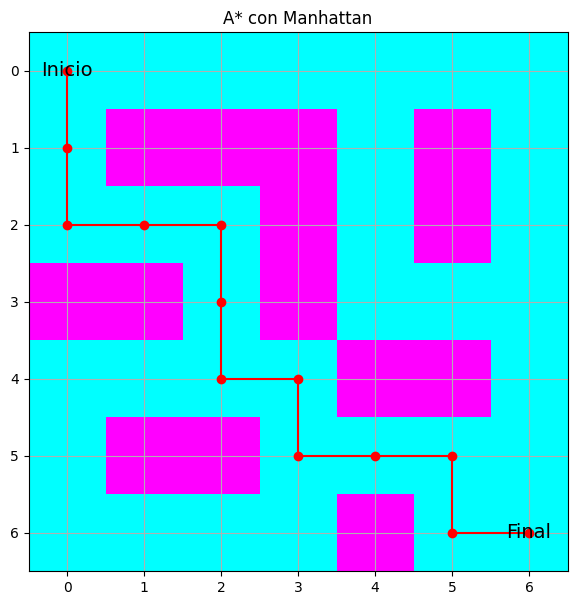

In [19]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

## 7.4 Comparación experimental

In [20]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29}}

# 8. Beam Search

Beam Search limita deliberadamente la cantidad de estados conservados en cada nivel.

$$k=\text{beam width}$$

Si $k=2$, solo se mantienen los dos estados más prometedores del nivel.

Ventaja: reduce memoria y exploración.  
Riesgo: puede descartar un estado que conduzca a la mejor solución. Por eso no garantiza optimalidad y puede fallar aunque exista solución.

In [21]:
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

resultado_beam=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=3)
resultado_beam

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 31,
 'beam_width': 3}

## 8.1 Experimentar con diferentes anchos de haz

In [22]:
resultados_beam={}
for k in [1,2,3,5,10]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: None,
 2: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 24,
  'beam_width': 2},
 3: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 31,
  'beam_width': 3},
 5: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 5},
 10: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 10}}

# 9. Comparación global

In [23]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]},
    "Beam Search k=3": None if resultado_beam is None else {"costo":resultado_beam["costo"],"expandidos":resultado_beam["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29},
 'Beam Search k=3': {'costo': 12, 'expandidos': 31}}

## 9.1 Resumen conceptual

| Algoritmo | Prioriza | Heurística | ¿Óptimo? | Memoria |
|---|---|---:|---|---|
| Costo Uniforme | menor $g(n)$ | No | Sí, con costos no negativos | Puede ser alta |
| A* | menor $g(n)+h(n)$ | Sí | Sí, bajo condiciones adecuadas | Puede ser alta |
| Beam Search | mejores $k$ candidatos | Sí | No garantizado | Controlada |

**Idea clave:**
- Costo Uniforme sabe cuánto ha costado llegar.
- A* sabe cuánto ha costado llegar y estima cuánto falta.
- Beam Search sacrifica exhaustividad para controlar el tamaño de la búsqueda.

# 10. Interpretación de la calidad de una heurística

Ya observamos tres escenarios:

- **Heurística nula:** no aporta información y A* se reduce a Costo Uniforme.
- **Heurística admisible:** orienta la búsqueda sin sobreestimar el costo real restante.
- **Heurística no admisible:** puede priorizar de forma agresiva ciertos caminos, pero pierde la garantía de optimalidad.

### Para discutir

1. ¿Una heurística con valores más grandes es necesariamente mejor?
2. ¿Qué diferencia existe entre una heurística **informativa** y una heurística que simplemente sobreestima?
3. ¿Por qué no podemos usar \(h^*(n)\) directamente como heurística en un problema real?
4. ¿Qué ocurriría si calcular \(h(n)\) fuera casi tan costoso como resolver el problema?
5. ¿Qué propiedades del dominio podrían utilizarse para construir una buena heurística?

### Respuestas

**1.** No, una heurística con valores más grandes no es mejor por sí sola. Si los valores crecen pero siguen siendo menores o iguales a $h^*(n)$ entonces sí ayuda, porque está más cerca del costo real y A* descarta más nodos, pero si se pasa de $h^*(n)$ ya sobreestima y A* puede terminar devolviendo un camino que no es el óptimo. Lo que importa es qué tan cerca está de $h^*(n)$ sin pasarse.

**2.** Una heurística informativa es la que se acerca bastante al costo real pero sin pasarse, entonces orienta bien la búsqueda y mantiene la garantía de optimalidad. Una que sobreestima también puede orientar (incluso de forma más agresiva y expandiendo menos nodos), pero lo hace "mintiendo" sobre lo que falta, lo cual genera que A* pueda descartar el camino correcto porque lo ve más caro de lo que realmente es. En el Caso 3 del notebook se ve eso, con $h(E)=7$ cuando el real es 2 la búsqueda castiga injustamente a E y termina devolviendo A-B-D-G con costo 11 en vez de 9.

**3.** Porque para conocer $h^*(n)$ hay que saber el costo mínimo real desde cada nodo hasta el objetivo, y eso ya es resolver el problema. En el ejemplo del grafo lo pudimos calcular porque el grafo es pequeño y conocemos todo, pero en un problema real si tuviéramos $h^*(n)$ no necesitaríamos buscar.

**4.** Se perdería la ventaja de usarla. La idea de la heurística es que sea barata de calcular y ahorre expansiones, entonces si calcular $h(n)$ cuesta casi lo mismo que resolver el problema, el tiempo que ahorramos en nodos expandidos lo perdemos calculando la heurística en cada nodo, y al final puede salir más lento que un Costo Uniforme normal.

**5.** Depende del dominio, pero en general sirven la geometría (distancia Manhattan o euclidiana en mapas), relajar restricciones del problema (por ejemplo en el 8-puzzle suponer que las fichas se pueden mover sin importar si la casilla está ocupada, que es de donde sale Manhattan), contar elementos fuera de lugar, límites físicos como velocidad máxima o costo mínimo por movimiento, y conocimiento de expertos del problema.

# 11. Reto: A* para el 8-puzzle

Compare tres estrategias sobre el mismo problema:

1. BFS
2. A* con fichas fuera de lugar
3. A* con distancia Manhattan

Mida:
- longitud de la solución;
- estados expandidos;
- tiempo de ejecución.

Heurísticas sugeridas:

$$h_1(n)=\text{número de fichas fuera de lugar}$$

$$h_2(n)=\sum_i (|x_i-x_i^*|+|y_i-y_i^*|)$$

In [24]:
from collections import deque
import time

OBJETIVO_8 = (1, 2, 3, 4, 5, 6, 7, 8, 0)

def vecinos_8(estado):
    i = estado.index(0)
    f, c = divmod(i, 3)
    out = []
    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc
        if 0 <= nf < 3 and 0 <= nc < 3:
            j = nf * 3 + nc
            s = list(estado)
            s[i], s[j] = s[j], s[i]
            out.append(tuple(s))
    return out

def reconstruir(padre, estado):
    camino = []
    while estado is not None:
        camino.append(estado)
        estado = padre[estado]
    return camino[::-1]

def fichas_fuera(estado, objetivo):
    return sum(1 for a, b in zip(estado, objetivo) if a != 0 and a != b)

def manhattan_8(estado, objetivo):
    pos = {v: divmod(i, 3) for i, v in enumerate(objetivo)}
    total = 0
    for i, v in enumerate(estado):
        if v != 0:
            f, c = divmod(i, 3)
            fo, co = pos[v]
            total += abs(f - fo) + abs(c - co)
    return total

def bfs_8_puzzle(estado_inicial, estado_objetivo):
    frontera = deque([estado_inicial])
    padre = {estado_inicial: None}
    expandidos = 0
    while frontera:
        estado = frontera.popleft()
        expandidos += 1
        if estado == estado_objetivo:
            camino = reconstruir(padre, estado)
            return {"longitud": len(camino) - 1, "expandidos": expandidos}
        for v in vecinos_8(estado):
            if v not in padre:
                padre[v] = estado
                frontera.append(v)
    return None

def astar_8_puzzle(estado_inicial, estado_objetivo, heuristica):
    tie = count()
    frontera = [(heuristica(estado_inicial, estado_objetivo), 0, next(tie), estado_inicial)]
    mejor_g = {estado_inicial: 0}
    padre = {estado_inicial: None}
    expandidos = 0
    while frontera:
        f, g, _, estado = heappop(frontera)
        if g != mejor_g.get(estado):
            continue
        expandidos += 1
        if estado == estado_objetivo:
            camino = reconstruir(padre, estado)
            return {"longitud": len(camino) - 1, "expandidos": expandidos}
        for v in vecinos_8(estado):
            ng = g + 1
            if ng < mejor_g.get(v, math.inf):
                mejor_g[v] = ng
                padre[v] = estado
                heappush(frontera, (ng + heuristica(v, estado_objetivo), ng, next(tie), v))
    return None

In [25]:
def medir(funcion, *args):
    t0 = time.perf_counter()
    r = funcion(*args)
    r["tiempo_s"] = round(time.perf_counter() - t0, 4)
    return r

def comparar_8_puzzle(inicial, objetivo=OBJETIVO_8):
    return {
        "BFS": medir(bfs_8_puzzle, inicial, objetivo),
        "A* fichas fuera": medir(astar_8_puzzle, inicial, objetivo, fichas_fuera),
        "A* Manhattan": medir(astar_8_puzzle, inicial, objetivo, manhattan_8),
    }

inicial_8 = (0, 4, 3, 8, 2, 6, 7, 5, 1)
comparar_8_puzzle(inicial_8)

{'BFS': {'longitud': 20, 'expandidos': 49735, 'tiempo_s': 0.1066},
 'A* fichas fuera': {'longitud': 20, 'expandidos': 3492, 'tiempo_s': 0.0143},
 'A* Manhattan': {'longitud': 20, 'expandidos': 570, 'tiempo_s': 0.0033}}

Las tres estrategias encuentran la solución de 20 movimientos, porque BFS con costo 1 por movimiento es óptimo y las dos heurísticas son admisibles. La diferencia está en el trabajo que hacen, BFS expande casi 50 mil estados, A* con fichas fuera de lugar unos 3500 y A* con Manhattan alrededor de 570, y el tiempo baja en la misma proporción.

# 12. Preguntas de cierre

1. ¿Cuál es la diferencia entre $g(n)$ y $h(n)$?
2. ¿Por qué Costo Uniforme no es una búsqueda heurística?
3. ¿Por qué A* puede expandir menos nodos que Costo Uniforme?
4. ¿Qué pierde Beam Search al limitar la frontera?
5. ¿Qué algoritmo elegiría si necesita garantizar la solución de menor costo?
6. ¿Cuál elegiría si dispone de memoria muy limitada?
7. ¿Qué papel cumple la calidad de la heurística?

### Respuestas

**1.** $g(n)$ es lo que ya se gastó para llegar desde el inicio hasta $n$, es un valor conocido. $h(n)$ es una estimación de lo que falta desde $n$ hasta el objetivo, no se sabe exacto sino que se aproxima.

**2.** Porque solo usa $g(n)$, que es información del camino ya recorrido, no tiene ninguna estimación de qué tan cerca está el objetivo. Expande hacia todos lados según el costo acumulado sin saber hacia dónde queda la meta.

**3.** Porque la heurística le dice hacia dónde queda el objetivo, entonces los nodos que se alejan de la meta tienen un $f(n)$ más alto y quedan de últimos en la cola, muchos ni se alcanzan a expandir. En la cuadrícula 7x7 se ve, UCS expandió más estados que A* con Manhattan y los dos llegaron al mismo costo.

**4.** Pierde completitud y optimalidad. Al quedarse solo con los $k$ mejores de cada nivel puede botar justamente el estado que llevaba a la mejor solución, o a la única, entonces puede devolver un camino más caro o no encontrar nada aunque exista solución.

**5.** A* con una heurística admisible (y consistente si hay grafo con estados repetidos), o Costo Uniforme si no tengo una buena heurística. Los dos garantizan la solución de menor costo, pero A* normalmente expande menos.

**6.** Beam Search, porque la memoria queda controlada por $k$, pero asumiendo que puedo aceptar que la solución no sea la óptima o que a veces no la encuentre.

**7.** Es lo que define qué tan eficiente es A*. Si la heurística es admisible y cercana a $h^*(n)$ la búsqueda expande pocos nodos y sigue siendo óptima, si es muy débil (como $h=0$) se vuelve Costo Uniforme, y si sobreestima puede ser rápida pero ya no garantiza el mejor camino. En el 8-puzzle se ve claro, Manhattan domina a fichas fuera de lugar y expande muchos menos estados.

# 13. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.

### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.

## Solución del taller

### Parte 1 — Cuadrícula 12 × 12

In [26]:
mapa12 = [
    [0,0,0,0,0,0,1,0,0,0,0,1],
    [0,1,1,1,0,0,0,0,0,0,0,1],
    [1,0,0,1,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,1,0,0,0,0],
    [0,0,1,1,0,0,0,1,0,0,1,0],
    [0,1,0,0,0,1,0,1,0,0,0,1],
    [0,1,0,0,1,0,1,0,0,0,0,0],
    [0,0,0,0,1,1,0,0,1,0,0,0],
    [0,0,0,0,1,0,1,0,0,1,0,1],
    [0,0,1,0,1,1,0,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,1,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,1,0],
]
INICIO12 = (0, 0)
OBJETIVO12 = (11, 11)

ucs12 = ucs_mapa(mapa12, INICIO12, OBJETIVO12)
astar12 = astar_mapa(mapa12, INICIO12, OBJETIVO12)
beam12 = {k: beam_search_mapa(mapa12, INICIO12, OBJETIVO12, beam_width=k) for k in [1, 2, 4, 8]}

tabla_parte1 = {
    "Costo Uniforme": {"costo": ucs12["costo"], "expandidos": ucs12["expandidos"]},
    "A*": {"costo": astar12["costo"], "expandidos": astar12["expandidos"]},
}
for k, r in beam12.items():
    tabla_parte1[f"Beam k={k}"] = {"costo": None, "expandidos": None, "encontro": False} if r is None \
        else {"costo": r["costo"], "expandidos": r["expandidos"], "encontro": True}
tabla_parte1

{'Costo Uniforme': {'costo': 22, 'expandidos': 106},
 'A*': {'costo': 22, 'expandidos': 46},
 'Beam k=1': {'costo': None, 'expandidos': None, 'encontro': False},
 'Beam k=2': {'costo': 28, 'expandidos': 48, 'encontro': True},
 'Beam k=4': {'costo': 28, 'expandidos': 66, 'encontro': True},
 'Beam k=8': {'costo': 22, 'expandidos': 104, 'encontro': True}}

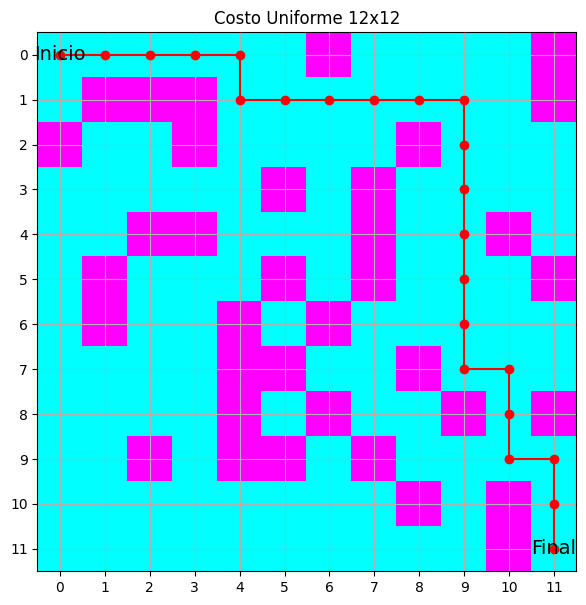

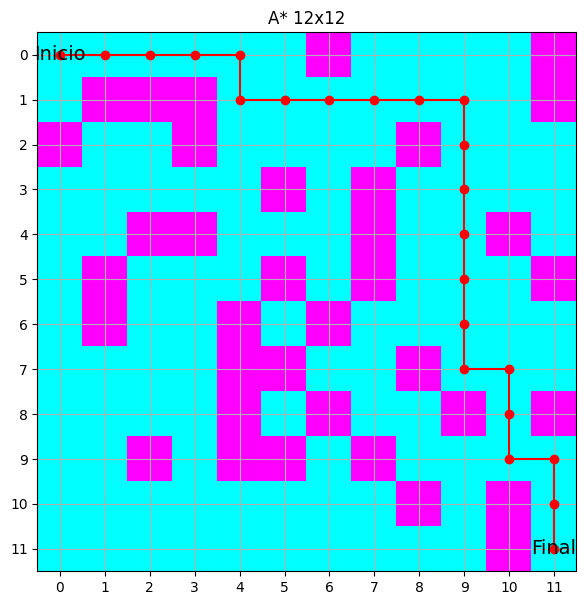

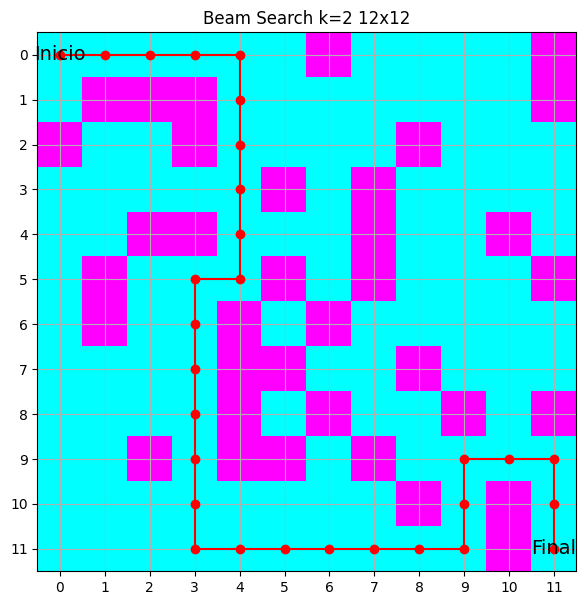

In [27]:
mostrar_mapa(mapa12, ucs12["camino"], INICIO12, OBJETIVO12, "Costo Uniforme 12x12")
mostrar_mapa(mapa12, astar12["camino"], INICIO12, OBJETIVO12, "A* 12x12")
mostrar_mapa(mapa12, beam12[2]["camino"], INICIO12, OBJETIVO12, "Beam Search k=2 12x12")

Costo Uniforme y A* llegan al mismo costo (22), que es el óptimo, pero A* expande menos de la mitad de estados (46 contra 106) porque Manhattan lo empuja hacia la esquina del objetivo. Con Beam Search se ve el problema de limitar la frontera, con $k=1$ se queda encerrado y no encuentra solución aunque sí existe, con $k=2$ y $k=4$ encuentra un camino de costo 28 que es más caro que el óptimo, y solo con $k=8$ llega al 22, pero ahí ya expande casi lo mismo que Costo Uniforme. Entonces entre más grande el haz más confiable, pero también se pierde la ventaja de ahorrar exploración.

### Parte 2 — Heurísticas

In [28]:
def euclidiana(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def astar_mapa_h(mapa, inicio, objetivo, h):
    tie = count()
    frontera = [(h(inicio, objetivo), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}
        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                heappush(frontera, (ng + h(vecino, objetivo), ng, next(tie), vecino, camino + [vecino]))
    return None

heuristicas_mapa = {"h=0": lambda a, b: 0, "Euclidiana": euclidiana, "Manhattan": manhattan}
{
    nombre: {k: v for k, v in astar_mapa_h(mapa12, INICIO12, OBJETIVO12, h).items() if k != "camino"}
    for nombre, h in heuristicas_mapa.items()
}

{'h=0': {'costo': 22, 'expandidos': 106},
 'Euclidiana': {'costo': 22, 'expandidos': 59},
 'Manhattan': {'costo': 22, 'expandidos': 46}}

Comparé Manhattan y Euclidiana (más $h=0$ como referencia). Las dos son admisibles en una cuadrícula con movimientos en 4 direcciones, porque ninguna puede ser mayor al número real de pasos, por eso las dos llegan al costo óptimo de 22. Pero Manhattan orienta mejor, expande 46 estados contra 59 de la Euclidiana, dado que la Euclidiana mide en línea recta y eso subestima más lo que falta cuando no hay movimientos en diagonal. Manhattan siempre es mayor o igual a la Euclidiana y sigue sin pasarse del costo real, entonces está más cerca de $h^*(n)$ y por eso descarta más nodos.

### Parte 3 — 8-puzzle

In [29]:
estados_prueba = {
    8: (0, 1, 3, 8, 2, 5, 4, 7, 6),
    14: (2, 6, 3, 1, 8, 5, 0, 4, 7),
    20: (0, 4, 3, 8, 2, 6, 7, 5, 1),
    24: (6, 7, 0, 1, 4, 3, 8, 5, 2),
}
resultados_8 = {f"profundidad {d}": comparar_8_puzzle(e) for d, e in estados_prueba.items()}
for caso, res in resultados_8.items():
    print(caso)
    for alg, r in res.items():
        print(f"   {alg:17} longitud={r['longitud']:3}  expandidos={r['expandidos']:7}  tiempo={r['tiempo_s']}s")

profundidad 8
   BFS               longitud=  8  expandidos=    244  tiempo=0.0004s
   A* fichas fuera   longitud=  8  expandidos=     16  tiempo=0.0001s
   A* Manhattan      longitud=  8  expandidos=     11  tiempo=0.0001s
profundidad 14
   BFS               longitud= 14  expandidos=   4676  tiempo=0.0084s
   A* fichas fuera   longitud= 14  expandidos=    229  tiempo=0.0009s
   A* Manhattan      longitud= 14  expandidos=     69  tiempo=0.0005s
profundidad 20
   BFS               longitud= 20  expandidos=  49735  tiempo=0.0844s
   A* fichas fuera   longitud= 20  expandidos=   3492  tiempo=0.0144s
   A* Manhattan      longitud= 20  expandidos=    570  tiempo=0.0033s
profundidad 24
   BFS               longitud= 24  expandidos= 128954  tiempo=0.207s
   A* fichas fuera   longitud= 24  expandidos=  18242  tiempo=0.0735s
   A* Manhattan      longitud= 24  expandidos=   2110  tiempo=0.0115s


En todos los casos las tres estrategias dan la misma longitud, entonces las tres son óptimas acá, la diferencia es la cantidad de trabajo. BFS crece muy rápido con la profundidad (de 244 a casi 129 mil estados), A* con fichas fuera de lugar reduce bastante, y A* con Manhattan es el mejor en todos los casos, en profundidad 24 expande unas 60 veces menos que BFS. Esto pasa porque Manhattan domina a fichas fuera de lugar, cada ficha mal ubicada suma al menos 1 en Manhattan, entonces siempre da un valor mayor o igual sin dejar de ser admisible.

### Pregunta final

Sí. En la Parte 1 Beam Search con $k=2$ expandió 48 estados, casi lo mismo que A* y muchos menos que Costo Uniforme, pero el camino que devolvió costó 28 en vez de 22, y con $k=1$ fue todavía más "rápido" pero directamente no encontró solución. Esto pasa porque para ir más rápido descarta estados de la frontera y a veces el que descarta es justo el que llevaba al mejor camino. Lo mismo se vio con la heurística que sobreestima en el grafo, A* expandió 5 nodos pero devolvió A-B-D-G con costo 11 cuando el óptimo es 9. En cambio A* con una heurística admisible como Manhattan también fue más rápido que Costo Uniforme y BFS pero sin perder calidad, entonces no es que más rápido siempre sea peor, depende de si la forma de acelerar mantiene o no las garantías de optimalidad.

# 14. Conclusiones y transición

- Costo Uniforme prioriza el costo acumulado.
- A* combina costo acumulado y estimación del costo restante.
- Una buena heurística puede reducir la exploración.
- Beam Search reduce el uso de recursos, pero sacrifica garantías.
